# Kernel trick e valutazione dei modelli

In questo notebook approfondiamo due temi collegati alla classificazione supervisionata:

1. il **kernel trick**, utile per applicare le SVM a problemi non linearmente separabili;
2. la **valutazione dei modelli**, necessaria per stimare quanto un modello generalizza su dati non visti.

Nel notebook precedente abbiamo visto che una SVM lineare cerca un iperpiano di separazione nello spazio delle feature.

Tuttavia, non tutti i dataset sono separabili linearmente.

In alcuni casi, una retta o un piano non bastano: serve una frontiera decisionale curva.

Il kernel trick permette di ottenere frontiere non lineari senza costruire esplicitamente tutte le feature dello spazio trasformato.


## Import e funzione per visualizzare le regioni decisionali

Per visualizzare il comportamento dei classificatori useremo una funzione `plot_decision_regions`.

Questa funzione costruisce una griglia di punti nello spazio delle feature, applica il classificatore a ogni punto e disegna le regioni decisionali.

In questo modo possiamo osservare graficamente la frontiera appresa dal modello.

Nel caso di una SVM lineare, la frontiera sarà una retta.

Nel caso di una SVM con kernel RBF, la frontiera potrà essere curva.

In [70]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', '*', 'o', '^', 'v', '*')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )
    
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f'Class {cl}',
            edgecolor='black'
        )

## Dataset circolare

Per mostrare il limite di una SVM lineare, usiamo un dataset circolare generato con `make_circles`.

Il dataset contiene due classi disposte in forma di cerchi concentrici.

Questo tipo di dataset non è separabile linearmente nello spazio originale.

Infatti, nel piano formato dalle due feature:

$$
x_1
$$

e:

$$
x_2
$$

non esiste una retta che separi correttamente il cerchio interno dal cerchio esterno.

La separazione naturale sarebbe una curva chiusa, simile a una circonferenza.

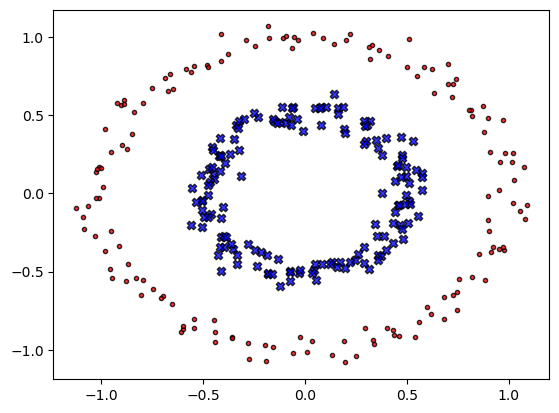

In [71]:
from sklearn.datasets import make_moons, make_circles

X, y = make_circles(
    n_samples=300,
    factor=0.5,   # raggio del cerchio interno
    noise=0.05,
    random_state=1
)
markers=['.', 'X']
colors = ['r', 'b']

for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

## SVM lineare sul dataset originale

Proviamo inizialmente ad addestrare una SVM lineare sul dataset originale.

Il modello `SVC(kernel='linear')` cerca una frontiera decisionale lineare.

Nel caso bidimensionale, questa frontiera è una retta.

Poiché il dataset è formato da due cerchi concentrici, una retta non riesce a separare bene le classi.

Ci aspettiamo quindi una accuracy limitata.

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [73]:
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
print("Accuracy SVM lineare:", np.mean(y_test == y_pred_linear))

Accuracy SVM lineare: 0.4444444444444444


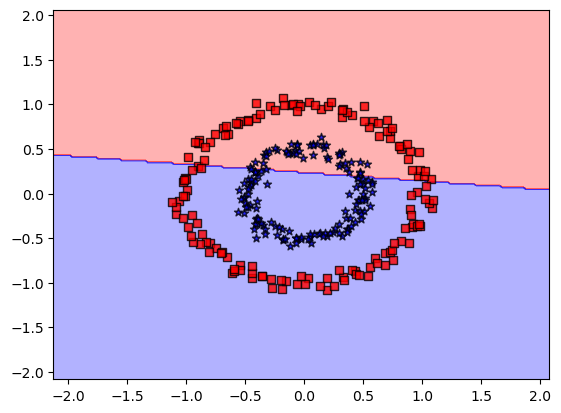

In [74]:
plot_decision_regions(X, y, linear_svm)

## Interpretazione

La SVM lineare prova a separare i dati con una retta.

Nel caso dei cerchi concentrici, questa ipotesi è troppo semplice.

Il modello è in una situazione di underfitting: la frontiera decisionale non è abbastanza flessibile per rappresentare la struttura del dataset.

Per separare correttamente le classi servirebbe una frontiera non lineare, ad esempio una curva simile a un cerchio.

## Trasformazione esplicita in una dimensione aggiuntiva

Per rendere il problema più semplice, possiamo trasformare lo spazio delle feature.

Nel dataset originale ogni punto è rappresentato da due coordinate:

$$
(x_1, x_2)
$$

Possiamo creare una nuova feature:

$$
z = x_1^2 + x_2^2
$$

Questa nuova feature misura la distanza quadratica del punto dall'origine.

I punti del cerchio interno avranno valori di $z$ più piccoli.

I punti del cerchio esterno avranno valori di $z$ più grandi.

Quindi passiamo da:

$$
(x_1, x_2)
$$

a:

$$
(x_1, x_2, z)
$$

dove:

$$
z = x_1^2 + x_2^2
$$

Nel nuovo spazio, una separazione che nel piano appariva circolare può diventare lineare.

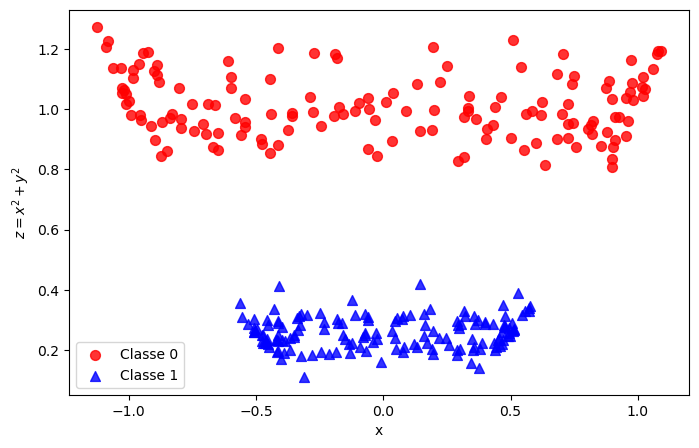

In [75]:
x1 = X[:, 0]
x2 = X[:, 1]

z = x1**2+x2**2

X_3d = np.c_[x1, x2, z]

markers = ['o', '^']
colors = ['red', 'blue']

# Plot 3D
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

for idx, cl in enumerate(np.unique(y)):
    ax.scatter(
        X_3d[y == cl, 0],
        X_3d[y == cl, 2],
        c=colors[idx],
        marker=markers[idx],
        s=50,
        alpha=0.8,
        label=f'Classe {cl}'
    )

# Etichette
ax.set_xlabel('x')

ax.set_ylabel(r'$z = x^2 + y^2$')

# Angolo di visualizzazione
#ax.view_init(elev=20, azim=45)

ax.legend()
plt.show()

## Nota sulla visualizzazione

La trasformazione porta i dati da due dimensioni:

$$
(x_1, x_2)
$$

a tre dimensioni:

$$
(x_1, x_2, z)
$$

dove:

$$
z = x_1^2 + x_2^2
$$

Nel grafico però non rappresentiamo l'intero spazio tridimensionale.

Per semplicità visualizziamo una proiezione bidimensionale usando:

$$
x_1
$$

sull'asse orizzontale e:

$$
z = x_1^2 + x_2^2
$$

sull'asse verticale.

Questa proiezione serve a mostrare che la nuova feature rende le classi più facilmente separabili.

## SVM lineare nello spazio trasformato

Ora addestriamo una SVM lineare non più sul dataset originale, ma sul dataset trasformato:

$$
X_{3d} = (x_1, x_2, x_1^2 + x_2^2)
$$

In questo nuovo spazio la SVM lineare ha più informazioni.

La separazione tra cerchio interno e cerchio esterno può essere rappresentata in modo più semplice.

Questo mostra l'idea alla base dei kernel:

> una separazione non lineare nello spazio originale può corrispondere a una separazione lineare in uno spazio trasformato.

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_3d, y, test_size=0.3, random_state=1
)

In [77]:
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
print("Accuracy SVM lineare:", np.mean(y_test == y_pred_linear))

Accuracy SVM lineare: 1.0


## Costo computazionale della trasformazione esplicita

Creare manualmente nuove feature può migliorare la separabilità dei dati.

Tuttavia, questa soluzione può diventare costosa quando il numero di feature cresce.

Se partiamo da `d` feature e aggiungiamo trasformazioni polinomiali, interazioni tra feature o altre funzioni non lineari, la dimensionalità può aumentare molto rapidamente.

Il costo di una SVM lineare dipende dal numero di feature.

Se il dataset originale ha dimensionalità `d`, ma dopo la trasformazione ha dimensionalità `D`, allora il costo dell'addestramento dipende da `D`.

In generale:

$$
D >> d
$$

può rendere il training più costoso sia in termini di tempo sia in termini di memoria.

Il kernel trick serve proprio a evitare di costruire esplicitamente tutte queste nuove feature.

## Kernel trick

Nel caso dei cerchi concentrici, abbiamo creato esplicitamente la feature:

$$
z = x_1^2 + x_2^2
$$

In questo modo siamo passati da uno spazio bidimensionale:

$$
(x_1, x_2)
$$

a uno spazio con una dimensione aggiuntiva:

$$
(x_1, x_2, z)
$$

Questa trasformazione può rendere i dati più facilmente separabili con un modello lineare.

Il problema è che, in generale, costruire esplicitamente nuove feature può essere molto costoso.

Se abbiamo molte feature iniziali, le trasformazioni possono generare uno spazio con un numero molto alto di dimensioni.

Il **kernel trick** permette di ottenere l'effetto di una trasformazione in uno spazio più grande senza calcolare esplicitamente tutte le nuove coordinate.

## Idea matematica del kernel trick

Indichiamo con:

$$
\phi(x)
$$

una funzione che trasforma un punto dallo spazio originale a uno spazio trasformato, solitamente con più dimensioni.

Una SVM lineare nello spazio trasformato lavora con prodotti scalari del tipo:

$$
\phi(x_i) \cdot \phi(x_j)
$$

Il kernel trick usa una funzione kernel:

$$
K(x_i, x_j)
$$

che calcola direttamente quel prodotto scalare:

$$
K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)
$$

senza costruire esplicitamente $\phi(x_i)$ e $\phi(x_j)$.

Quindi, invece di trasformare davvero i dati, usiamo una funzione che misura la similarità tra due punti come se fossero stati trasformati in uno spazio più grande.

## Kernel RBF

Uno dei kernel più usati è il kernel RBF, cioè Radial Basis Function.

La sua formula è:

$$
K(x_i, x_j) =
\exp \left( -\gamma ||x_i - x_j||^2 \right)
$$

Il kernel RBF misura la similarità tra due punti in base alla loro distanza.

Se due punti sono vicini, allora:

$$
||x_i - x_j||^2 \approx 0
$$

e quindi:

$$
K(x_i, x_j) \approx e^0 = 1
$$

Se due punti sono lontani, allora:

$$
||x_i - x_j||^2
$$

è grande e il valore del kernel tende a 0.

Quindi:

```text
punti vicini  -> similarità alta
punti lontani -> similarità bassa
```

## Ruolo di gamma

Nel kernel RBF compare il parametro:

$$
\gamma
$$

La formula è:

$$
K(x_i, x_j) =
\exp \left( -\gamma ||x_i - x_j||^2 \right)
$$

Il parametro $\gamma$ controlla quanto velocemente la similarità diminuisce con la distanza.

Se $\gamma$ è piccolo, anche punti relativamente lontani risultano ancora simili.

Questo produce una frontiera decisionale più liscia e meno complessa.

Se $\gamma$ è grande, solo punti molto vicini risultano simili.

Questo produce una frontiera decisionale più locale e più complessa.

In sintesi:

```text
gamma piccolo:
frontiera più liscia
modello meno flessibile
rischio underfitting

gamma grande:
frontiera più complessa
modello più flessibile
rischio overfitting
```

## SVM con kernel RBF

Ora torniamo al dataset originale dei cerchi concentrici.

Invece di costruire esplicitamente la feature:

$$
z = x_1^2 + x_2^2
$$

usiamo direttamente una SVM con kernel RBF.

Il modello viene creato con:

`SVC(kernel='rbf', gamma=100)`

Il parametro `kernel='rbf'` indica che vogliamo usare il kernel RBF.

Il parametro `gamma=100` rende la frontiera decisionale molto flessibile, perché la similarità tra punti diminuisce rapidamente con la distanza.

Su un dataset come `make_circles`, una frontiera non lineare può separare molto meglio le due classi rispetto a una retta.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

rbf_svm = SVC(kernel='rbf', gamma=100)
rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)
print("Accuracy SVM RBF:", np.mean(y_test == y_pred_rbf))

Accuracy SVM RBF: 1.0


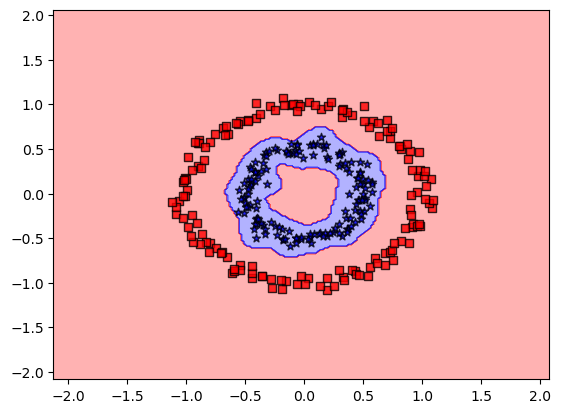

In [79]:
plot_decision_regions(X, y, rbf_svm)

## Interpretazione del risultato

La SVM lineare sul dataset originale cercava di separare i cerchi con una retta.

Questo non era adatto alla struttura del dataset, perché le classi sono disposte in modo circolare.

La SVM con kernel RBF, invece, riesce a costruire una frontiera decisionale non lineare.

La frontiera può seguire meglio la forma dei dati e separare il cerchio interno da quello esterno.

È importante ricordare che la SVM non disegna direttamente una curva nel senso geometrico classico.

L'idea è che il kernel RBF permette alla SVM di lavorare come se i dati fossero rappresentati in uno spazio trasformato, dove una separazione lineare può corrispondere a una frontiera curva nello spazio originale.

## Costo computazionale del kernel trick

Il kernel trick evita di costruire esplicitamente tutte le feature dello spazio trasformato.

Questo è utile quando la trasformazione avrebbe dimensionalità molto alta.

Tuttavia, usare un kernel non è gratuito.

Una SVM con kernel deve confrontare gli esempi tra loro attraverso la funzione kernel.

Se abbiamo `n` esempi, la matrice dei kernel contiene valori del tipo:

$$
K(x_i, x_j)
$$

per molte coppie di esempi.

La dimensione della matrice kernel è:

$$
n \times n
$$

Quindi la memoria può crescere come:

$$
O(n^2)
$$

Questo rende le SVM con kernel molto efficaci su dataset piccoli o medi, ma meno adatte a dataset molto grandi.

In sintesi:

```text
kernel trick:
evita di creare esplicitamente feature ad alta dimensionalità

ma:
richiede confronti tra coppie di esempi

costo/memoria:
può crescere molto quando aumenta il numero di esempi
```

# Valutare un modello


![bias](materiale_2026/18_01.png)


Dopo aver addestrato un modello, non basta controllare se funziona bene sui dati di training.

L'obiettivo del machine learning supervisionato è costruire un modello capace di generalizzare, cioè di fare buone predizioni su dati nuovi, mai visti durante l'addestramento.

Per questo motivo è necessario separare i dati in almeno due insiemi:

- training set;
- test set.

Il training set viene usato per addestrare il modello.

Il test set viene usato per stimare le prestazioni del modello su dati non visti.

Se un modello ottiene buone prestazioni sul training set ma cattive prestazioni sul test set, probabilmente sta facendo overfitting.



## Bias e varianza

Quando valutiamo un modello, due concetti importanti sono:

- bias;
- varianza.

Un modello con bias elevato è troppo semplice rispetto al problema.

In questo caso il modello commette errori sistematici e non riesce a rappresentare bene la relazione tra feature e target.

Questo porta a underfitting.

Un modello con varianza elevata è troppo sensibile ai dati di training.

In questo caso il modello si adatta troppo ai dati su cui è stato addestrato, inclusi rumore e particolarità casuali.

Questo porta a overfitting.

In sintesi:

```text
bias alto:
modello troppo semplice
errore alto su training e test
underfitting

varianza alta:
modello troppo complesso
errore basso su training
errore alto su test
overfitting
```

## Regolarizzazione e varianza

La regolarizzazione serve a limitare la complessità del modello.

Nel caso di modelli lineari, un esempio classico è la regolarizzazione L2:

$$
\frac{\lambda}{2} ||w||^2
$$

Questo termine penalizza pesi troppo grandi.

Pesi molto grandi possono rendere il modello troppo sensibile alle variazioni dei dati.

Penalizzando i valori estremi dei pesi, la regolarizzazione tende a ridurre la varianza.

Nel caso delle SVM, anche gli iperparametri come `C` e `gamma` influenzano il compromesso tra bias e varianza.

- `C` grande: penalizza molto gli errori, modello più rigido sui dati di training, rischio overfitting;
- `C` piccolo: tollera più errori, modello più regolarizzato, rischio underfitting;
- `gamma` grande: frontiera più locale e complessa, rischio overfitting;
- `gamma` piccolo: frontiera più liscia, rischio underfitting.

In [80]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

## Dataset sintetico per la valutazione

Creiamo un dataset sintetico di classificazione binaria.

Il dataset contiene:

- 300 esempi;
- 20 feature;
- 5 feature informative;
- 2 feature ridondanti;
- 2 classi;
- una certa quantità di rumore nelle etichette.

Il parametro `flip_y=0.10` introduce rumore: circa il 10% delle etichette può essere alterato.

Questo rende il problema più realistico, perché nei dati reali possono esserci errori, rumore o ambiguità.

In [81]:
# ==========================================================
# 1. Dataset sintetico con un po' di rumore
# ==========================================================
X, y = make_classification(
    n_samples=300, # 1000
    n_features=20,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    flip_y=0.10,       # 10% di rumore
    class_sep=0.8,
    random_state=1
)

## Perché ripetere lo split train/test?

Il risultato ottenuto su un test set può dipendere da come i dati vengono divisi.

Se cambiamo il valore di `random_state`, cambiano gli esempi che finiscono nel training set e nel test set.

Di conseguenza, anche la test accuracy può cambiare.

Questo è particolarmente evidente quando:

- il dataset è piccolo;
- il dataset contiene rumore;
- il modello è sensibile ai dati di training;
- il test set contiene pochi esempi.

Nel codice seguente ripetiamo lo split più volte usando valori diversi di `random_state`.

Per ogni split:

1. dividiamo il dataset in training set e test set;
2. addestriamo una SVM con kernel RBF;
3. calcoliamo la test accuracy;
4. salviamo il risultato.

Alla fine calcoliamo la varianza delle accuracy ottenute.

In [82]:
accuracies = []
# ==========================================================
# Proviamo diversi random_state
# ==========================================================
for seed in range(10):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        stratify=y,
        random_state=seed
    )

    # Modello SVM
    model = SVC(
        kernel='rbf',
        C = 0.5, # 1
        gamma = 0.1 # 0.5
    )

    # Training
    model.fit(X_train, y_train)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = np.mean(y_test==y_test_pred)

    accuracies.append(test_acc)
    print( f"Test Accuracy = {test_acc:.4f}")

print(f"Accuracies variance = {np.var(np.array(accuracies))}")

Test Accuracy = 0.7333
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.7333
Test Accuracy = 0.7556
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.7333
Test Accuracy = 0.7111
Accuracies variance = 0.0020740740740740732


## Interpretazione

Le accuracy stampate possono essere diverse tra loro anche se il modello e gli iperparametri sono gli stessi.

L'unica cosa che cambia è il modo in cui il dataset viene diviso in training set e test set.

Questo mostra che una singola divisione train/test può dare una stima instabile delle prestazioni.

Se per caso il test set contiene esempi più facili, l'accuracy può sembrare alta.

Se invece contiene esempi più difficili o rumorosi, l'accuracy può sembrare più bassa.

Per questo motivo non dovremmo basarci ciecamente su una sola accuracy ottenuta da un solo split.

La varianza delle accuracy misura quanto i risultati cambiano al variare dello split.

Una varianza alta indica che la valutazione è instabile.

## Costo computazionale di questa valutazione

In questo esperimento il modello viene addestrato più volte.

Se il costo di un singolo training è:

$$
T_{train}
$$

e ripetiamo l'esperimento per 10 split diversi, il costo totale è circa:

$$
10 \cdot T_{train}
$$

Quindi ripetere la valutazione aumenta il costo computazionale, ma fornisce una stima più robusta delle prestazioni.

Nel caso di SVM con kernel RBF, il costo può crescere molto con il numero di esempi, perché il modello deve confrontare i punti tramite la funzione kernel.

## Collegamento con bias e varianza

Se un modello ha alta varianza, tende a dipendere molto dai dati usati per l'addestramento.

Cambiando leggermente il training set, il modello appreso può cambiare molto.

Di conseguenza, anche le prestazioni sul test set possono variare.

Questo esperimento mostra proprio questa idea:

```text
stesso algoritmo
stessi iperparametri
stesso dataset

ma split diversi
producono accuracy diverse
```

Per ottenere una valutazione più robusta, possiamo usare strategie più strutturate, come:

- metodo holdout con training, validation e test set;
- cross validation.

## Metodo holdout

Il metodo holdout consiste nel dividere il dataset in insiemi separati con ruoli diversi.

In questa lezione usiamo tre insiemi:

- training set;
- validation set;
- test set.

Il training set viene usato per addestrare il modello.

Il validation set viene usato per confrontare modelli diversi o scegliere gli iperparametri.

Il test set viene usato solo alla fine, per stimare le prestazioni finali del modello scelto.

La regola importante è:

```text
il test set non deve essere usato per scegliere il modello
```

Se usassimo il test set per scegliere gli iperparametri, il test non sarebbe più una valutazione imparziale.

## Nuovo dataset sintetico

Creiamo un dataset sintetico più grande rispetto all'esempio precedente.

Il dataset contiene:

- 1500 esempi;
- 20 feature;
- 8 feature informative;
- 4 feature ridondanti;
- 2 classi;
- 5% di rumore nelle etichette.

Il rumore viene introdotto tramite:

`flip_y=0.05`

Questo significa che una piccola percentuale delle etichette può essere alterata.

Lo scopo è simulare un problema più realistico, in cui i dati non sono perfetti.

In [83]:
# ==========================================================
# Dataset sintetico con un po' di rumore
# ==========================================================
X, y = make_classification(
    n_samples=1500,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_classes=2,
    flip_y=0.05,       # 5% di etichette errate
    class_sep=1.0,
    random_state=1
)

## Suddivisione in training, validation e test set

La lezione divide il dataset in tre parti.

Prima viene separato il test set:

```text
Test set = 15% del dataset totale
```

Il restante 85% viene salvato in `X_temp` e `y_temp`.

Poi da `X_temp` viene ricavato il validation set.

Dato che `X_temp` rappresenta l'85% del dataset totale, per ottenere un validation set pari al 15% del totale bisogna usare:

$$
\frac{15}{85} \approx 0.17647
$$

Quindi:

```text
Training set   ≈ 70% del totale
Validation set ≈ 15% del totale
Test set       ≈ 15% del totale
```

Il parametro `stratify=y` serve a mantenere proporzioni simili tra le classi nei vari split.

In [84]:
# Test set = 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=0
)

# Validation set = 15% del totale
# X_temp = 85% del totale -> 15/85 = 0.17647
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.17647,
    stratify=y_temp,
    random_state=0
)

print("Training set   :", len(X_train))
print("Validation set :", len(X_val))
print("Test set       :", len(X_test))

Training set   : 1050
Validation set : 225
Test set       : 225


## Confronto tra due modelli

Ora confrontiamo due SVM con kernel RBF ma con iperparametri diversi.

Il primo modello usa:

```text
C = 1
gamma = 1.5
```

Un valore alto di `gamma` rende la frontiera decisionale più locale e complessa.

Questo può portare ad alta varianza, cioè overfitting.

Il secondo modello usa:

```text
C = 0.5
gamma = 0.01
```

Un valore più basso di `gamma` rende la frontiera più liscia.

Questo riduce la varianza, ma se il modello diventa troppo semplice può aumentare il bias.

Confrontiamo i modelli usando il validation set, non il test set.

In [85]:
# ==========================================================
# MODELLO 1
# ==========================================================
model1 = SVC(
    kernel='rbf',
    C=1,
    gamma=1.5,
    random_state=1
)

model1.fit(X_train, y_train)

# Accuracy sul training set
train_pred_1 = model1.predict(X_train)
train_acc_1 = np.mean(y_train == train_pred_1)

# Accuracy sul validation set
val_pred_1 = model1.predict(X_val)
val_acc_1 =  np.mean(y_val == val_pred_1)

print("\nMODELLO 1 (alta varianza)")
print(f"Training accuracy   : {train_acc_1:.4f}")
print(f"Validation accuracy : {val_acc_1:.4f}")


MODELLO 1 (alta varianza)
Training accuracy   : 1.0000
Validation accuracy : 0.5022


In [86]:
# ==========================================================
# MODELLO 2
# ==========================================================
model2 = SVC(
    kernel='rbf',
    C=0.5,
    gamma=0.01,
    random_state=1
)

model2.fit(X_train, y_train)

# Accuracy sul training set
train_pred_2 = model2.predict(X_train)
train_acc_2 = np.mean(y_train==train_pred_2)

# Accuracy sul validation set
val_pred_2 = model2.predict(X_val)
val_acc_2 = np.mean(y_val==val_pred_2)

print("\nMODELLO 2 (varianza ridotta)")
print(f"Training accuracy   : {train_acc_2:.4f}")
print(f"Validation accuracy : {val_acc_2:.4f}")


MODELLO 2 (varianza ridotta)
Training accuracy   : 0.9114
Validation accuracy : 0.9067


## Interpretazione del confronto

Il modello migliore non è necessariamente quello con accuracy più alta sul training set.

Un modello può ottenere accuracy molto alta sul training set perché si è adattato troppo ai dati di addestramento.

Quello che ci interessa è la capacità di generalizzare.

Per questo confrontiamo i modelli usando il validation set.

Se un modello ha:

```text
training accuracy alta
validation accuracy molto più bassa
```

probabilmente sta facendo overfitting.

Se invece training accuracy e validation accuracy sono più vicine, il modello tende a generalizzare meglio.

In [87]:
# ==========================================================
# Scelta del modello migliore
# ==========================================================
if val_acc_2 > val_acc_1:
    best_model = model2
    print("\nIl Modello 2 è migliore sul validation set.")
else:
    best_model = model1
    print("\nIl Modello 1 è migliore sul validation set.")


Il Modello 2 è migliore sul validation set.


## Riaddestramento finale

Dopo aver scelto il modello migliore usando il validation set, possiamo riaddestrarlo usando sia il training set sia il validation set.

Questo perché il validation set ha ormai svolto il suo ruolo: ci è servito per scegliere il modello.

A questo punto possiamo usare più dati possibile per addestrare il modello finale.

Uniamo quindi:

```text
training set + validation set
```

e addestriamo di nuovo il modello migliore.

Solo dopo valutiamo il risultato sul test set.

Il test set resta separato fino alla fine.

In [88]:
# ==========================================================
# Riaddestramento finale su Train + Validation
# ==========================================================
X_train_final = np.vstack([X_train, X_val])
y_train_final = np.hstack([y_train, y_val])

best_model.fit(X_train_final, y_train_final)

# ==========================================================
# Valutazione finale sul Test Set
# ==========================================================
y_test_pred = best_model.predict(X_test)
test_acc = np.mean(y_test==y_test_pred)

print(f"\nAccuracy finale sul Test Set: {test_acc:.4f}")


Accuracy finale sul Test Set: 0.8800


## Limite del metodo holdout

Il metodo holdout è semplice e intuitivo, ma ha un limite.

La scelta del modello dipende da una singola divisione dei dati in:

```text
training set
validation set
test set
```

Se il validation set contiene esempi particolarmente facili o difficili, la scelta del modello può essere influenzata dal caso.

Questo problema è più evidente quando il dataset è piccolo.

Per ottenere una valutazione più stabile possiamo usare la cross validation.

## Convalida incrociata

La convalida incrociata, o cross validation, divide il dataset in più parti chiamate fold.

Se usiamo una k-fold cross validation con:

$$
k = 5
$$

il dataset viene diviso in 5 fold.

Il modello viene addestrato 5 volte.

Ogni volta:

- 4 fold vengono usati per il training;
- 1 fold viene usato per la validazione.

Alla fine otteniamo 5 accuracy di validazione.

La prestazione del modello viene stimata facendo la media delle accuracy ottenute sui fold.

Questo riduce la dipendenza da un singolo validation set.

## Stratified K-Fold

Nel caso della classificazione è spesso utile usare `StratifiedKFold`.

La stratificazione cerca di mantenere proporzioni simili tra le classi in ogni fold.

Questo è importante soprattutto quando le classi non sono perfettamente bilanciate.

Nel codice seguente usiamo un esempio molto piccolo per vedere quali indici finiscono nel training set e quali nel validation set.

In [89]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

X = range(12)
y = [0,1,1,1,0,1,1,1,0,0,1,0]

for train_idx, val_idx in kf.split(X, y):
    print(train_idx, val_idx)

[ 0  1  2  3  5  7  8 10 11] [4 6 9]
[ 2  3  4  5  6  7  8  9 11] [ 0  1 10]
[ 0  1  2  3  4  6  8  9 10] [ 5  7 11]
[ 0  1  4  5  6  7  9 10 11] [2 3 8]


## Interpretazione dei fold

Il dataset viene diviso in 4 parti.

A ogni iterazione, una parte viene usata come validation set e le parti rimanenti vengono usate come training set.

Quindi ogni esempio viene usato:

- più volte per il training;
- una volta per la validazione.

Questo permette di ottenere una stima più robusta delle prestazioni rispetto a un singolo split holdout.

## Cross validation per la scelta degli iperparametri

Ora usiamo la cross validation per scegliere gli iperparametri di una SVM con kernel RBF.

Gli iperparametri da confrontare sono:

- `C`;
- `gamma`.

Il test set viene comunque lasciato da parte e non viene usato nella cross validation.

La procedura è:

1. separare un test set finale;
2. usare il resto dei dati per la cross validation;
3. provare diverse combinazioni di `C` e `gamma`;
4. calcolare la media delle accuracy sui fold;
5. scegliere la combinazione con accuracy media migliore;
6. addestrare il modello finale su tutto il training set disponibile;
7. valutare una sola volta sul test set.

In [90]:
# ==========================================================
# 1. Dataset sintetico
# ==========================================================
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_classes=2,
    flip_y=0.08,
    class_sep=0.9,
    random_state=1
)

In [91]:
# ==========================================================
# K-Fold Cross Validation
# ==========================================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

In [92]:
# ==========================================================
# HOLD OUT DEL TEST SET (mai toccato)
# ==========================================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=1
)

## Griglia di iperparametri

Definiamo i valori di `C` e `gamma` da testare.

Nel codice della lezione:

```text
C_values = [0.1, 1, 10, 12, 15, 17]
gamma_values = [0.01]
```

In questo caso viene variato solo `C`, mentre `gamma` resta fisso a `0.01`.

Per ogni combinazione di iperparametri verrà eseguita una cross validation a 5 fold.

In [93]:
# ==========================================================
# Iperparametri da testare
# ==========================================================
C_values = [0.1, 1, 10, 12, 15, 17]
gamma_values = [#0.001,
    0.01,
    #0.1
    ]

best_score = 0
best_params = None

In [94]:
# ==========================================================
# Loop sugli iperparametri
# ==========================================================
for C in C_values:
    for gamma in gamma_values:

        fold_scores = []

        # ======================================================
        # Cross-validation
        # ======================================================
        for train_idx, val_idx in kf.split(X_train_full, y_train_full):

            X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
            y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

            model = SVC(kernel="rbf", C=C, gamma=gamma)

            model.fit(X_train, y_train)
            preds = model.predict(X_val)

            acc = np.mean(y_val==preds)
            fold_scores.append(acc)

        mean_score = np.mean(fold_scores)

        print(f"C={C:<3} gamma={gamma:<5} -> CV accuracy = {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = (C, gamma)

C=0.1 gamma=0.01  -> CV accuracy = 0.8424
C=1   gamma=0.01  -> CV accuracy = 0.8682
C=10  gamma=0.01  -> CV accuracy = 0.8729
C=12  gamma=0.01  -> CV accuracy = 0.8729
C=15  gamma=0.01  -> CV accuracy = 0.8671
C=17  gamma=0.01  -> CV accuracy = 0.8659


## Interpretazione del loop

Il ciclo esterno prova tutte le combinazioni di `C` e `gamma`.

Per ogni combinazione, viene eseguita una cross validation.

Dentro la cross validation:

1. `kf.split(X_train_full, y_train_full)` genera gli indici di training e validation per ogni fold;
2. il modello viene addestrato sul training fold;
3. il modello viene valutato sul validation fold;
4. l'accuracy del fold viene salvata in `fold_scores`.

Alla fine dei fold viene calcolata:

$$
mean\_score = media(fold\_scores)
$$

Questa media rappresenta la stima della qualità di quella combinazione di iperparametri.

La combinazione con la media migliore viene salvata in:

```text
best_params
```

In [95]:
# ==========================================================
# Migliori iperparametri
# ==========================================================
print("\nMigliori iperparametri trovati:")
print("C =", best_params[0], "gamma =", best_params[1])
print("CV accuracy media =", best_score)


Migliori iperparametri trovati:
C = 10 gamma = 0.01
CV accuracy media = 0.8729411764705881


## Addestramento del modello finale

Dopo aver scelto i migliori iperparametri tramite cross validation, addestriamo il modello finale.

Il modello finale viene addestrato su tutto `X_train_full`.

Questo insieme contiene tutti i dati disponibili tranne il test set finale.

Il test set non è stato usato né per addestrare i modelli durante la cross validation né per scegliere gli iperparametri.

In questo modo il test set rimane una valutazione finale indipendente.

In [96]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVC(
    kernel="rbf",
    C=best_params[0],
    gamma=best_params[1]
)

final_model.fit(X_train_full, y_train_full)

print("\nModello finale addestrato su tutto il dataset.")


Modello finale addestrato su tutto il dataset.


In [97]:
# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)

print("\nMigliori parametri:", best_params)
print("Test accuracy finale:", test_acc)


Migliori parametri: (10, 0.01)
Test accuracy finale: 0.8466666666666667


## Costo computazionale della cross validation

La cross validation è più robusta di un singolo holdout, ma è anche più costosa.

Supponiamo di avere:

- `k` fold;
- `m` combinazioni di iperparametri;
- costo di un singolo training pari a $T_{train}$.

Il costo totale è circa:

$$
m \cdot k \cdot T_{train}
$$

Nel nostro caso:

- `k = 5`;
- `m = numero di combinazioni tra C e gamma`.

Poiché `gamma_values` contiene un solo valore e `C_values` contiene 6 valori:

$$
m = 6
$$

Quindi il numero di addestramenti è:

$$
6 \cdot 5 = 30
$$

Dopo la scelta degli iperparametri, viene fatto anche un addestramento finale su tutto il training set disponibile.

Quindi il costo totale è circa:

$$
30 + 1
$$

addestramenti.

Questo costo aggiuntivo è il prezzo da pagare per ottenere una scelta degli iperparametri più stabile.

## Holdout vs cross validation

Il metodo holdout è semplice e veloce.

Divide il dataset una sola volta in training, validation e test set.

Il problema è che la valutazione dipende molto da quella singola divisione.

La cross validation usa invece più divisioni del dataset.

Ogni fold viene usato una volta come validation set.

Questo rende la stima delle prestazioni più stabile.

In sintesi:

```text
holdout:
più veloce
più semplice
più sensibile allo split

cross validation:
più costosa
più robusta
più adatta alla scelta degli iperparametri
```

In entrambi i casi, il test set finale deve essere usato solo alla fine.

In [98]:
test_pred = final_model.predict(X_test)

# Matrice di confusione

L'accuracy misura la percentuale complessiva di predizioni corrette.

Tuttavia, l'accuracy da sola non sempre basta per capire bene gli errori del modello.

Per analizzare meglio le predizioni possiamo usare la matrice di confusione.

Nel caso di classificazione binaria, la matrice di confusione confronta:

- le classi reali;
- le classi predette dal modello.

La matrice permette di distinguere tra diversi tipi di errore.

## Struttura della matrice di confusione

Nel caso binario, la matrice di confusione ha questa struttura:

$$
\begin{bmatrix}
TN & FP \\\\
FN & TP
\end{bmatrix}
$$

dove:

- `TN` significa True Negative;
- `FP` significa False Positive;
- `FN` significa False Negative;
- `TP` significa True Positive.

In `sklearn`, per default, la matrice viene costruita ordinando le classi in ordine crescente.

Quindi, se le classi sono `0` e `1`:

```text
riga 0: classe reale 0
riga 1: classe reale 1

colonna 0: classe predetta 0
colonna 1: classe predetta 1
```

## Significato di TP, TN, FP e FN

Supponiamo che la classe positiva sia la classe `1`.

### True Positive

Un True Positive è un esempio realmente positivo che il modello predice come positivo.

```text
classe reale = 1
classe predetta = 1
```

### True Negative

Un True Negative è un esempio realmente negativo che il modello predice come negativo.

```text
classe reale = 0
classe predetta = 0
```

### False Positive

Un False Positive è un esempio realmente negativo che il modello predice come positivo.

```text
classe reale = 0
classe predetta = 1
```

È un falso allarme.

### False Negative

Un False Negative è un esempio realmente positivo che il modello predice come negativo.

```text
classe reale = 1
classe predetta = 0
```

È un positivo che il modello non ha riconosciuto.

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred)

print("Matrice di confusione:")
print(cm)

Matrice di confusione:
[[65  7]
 [16 62]]


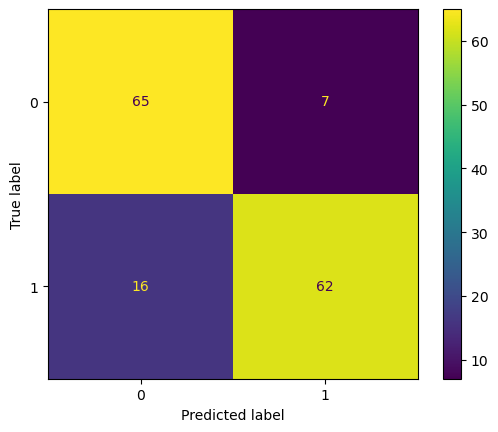

In [100]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Interpretazione della matrice

La matrice di confusione mostra quanti esempi finiscono in ciascuna categoria.

Se la matrice è:

$$
\begin{bmatrix}
TN & FP \\\\
FN & TP
\end{bmatrix}
$$

allora:

- in alto a sinistra ci sono i veri negativi;
- in alto a destra ci sono i falsi positivi;
- in basso a sinistra ci sono i falsi negativi;
- in basso a destra ci sono i veri positivi.

Gli elementi sulla diagonale principale rappresentano le predizioni corrette.

Gli elementi fuori dalla diagonale rappresentano gli errori.

In [101]:
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(tn, fp, fn, tp)

65 7 16 62


## Precision

La precision misura quanto sono affidabili le predizioni positive del modello.

La formula è:

$$
Precision =
\frac{TP}{TP + FP}
$$

Il denominatore contiene tutti gli esempi che il modello ha predetto come positivi.

Quindi la precision risponde alla domanda:

```text
Tra tutti gli esempi che il modello ha predetto come positivi,
quanti erano davvero positivi?
```

Una precision alta significa che, quando il modello predice la classe positiva, tende ad avere ragione.

La precision è importante quando vogliamo ridurre i falsi positivi.

## Recall

La recall misura quanti positivi reali il modello riesce a trovare.

La formula è:

$$
Recall =
\frac{TP}{TP + FN}
$$

Il denominatore contiene tutti gli esempi realmente positivi.

Quindi la recall risponde alla domanda:

```text
Tra tutti gli esempi davvero positivi,
quanti sono stati riconosciuti dal modello?
```

Una recall alta significa che il modello perde pochi positivi.

La recall è importante quando vogliamo ridurre i falsi negativi.

In [102]:
precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)


Precision: 0.8985507246376812
Recall: 0.7948717948717948


## Precision vs Recall

Precision e recall misurano due aspetti diversi.

La precision guarda le predizioni positive fatte dal modello.

La recall guarda i positivi reali presenti nel dataset.

Possiamo ricordarle così:

```text
Precision:
quanto mi posso fidare quando il modello dice positivo?

Recall:
quanti positivi reali sono riuscito a trovare?
```

Spesso esiste un compromesso tra precision e recall.

Aumentare la precision può ridurre la recall.

Aumentare la recall può ridurre la precision.

La metrica più importante dipende dal problema.

## Esempio intuitivo

Supponiamo di costruire un modello per rilevare una malattia.

Un False Positive significa:

```text
il modello dice malato
ma la persona non è malata
```

Un False Negative significa:

```text
il modello dice sano
ma la persona è malata
```

In questo caso i falsi negativi possono essere molto gravi, perché una persona malata non viene individuata.

Quindi potremmo preferire una recall alta.

Invece, in un sistema antispam, un falso positivo significa che una email valida viene classificata come spam.

In quel caso potremmo voler aumentare la precision, per evitare di bloccare email legittime.

## Costo computazionale della matrice di confusione

Supponiamo di avere:

- `n` esempi nel test set;
- `k` classi.

Per costruire la matrice di confusione dobbiamo confrontare, per ogni esempio, la classe reale e la classe predetta.

Il costo temporale è:

$$
O(n)
$$

La memoria necessaria per la matrice è:

$$
O(k^2)
$$

Nel caso binario:

$$
k = 2
$$

quindi la matrice ha dimensione:

$$
2 \times 2
$$

e la memoria è costante rispetto al numero di esempi.

## F1 score

Precision e recall misurano due aspetti diversi delle prestazioni del modello.

La precision risponde alla domanda:

```text
Tra tutti gli esempi predetti come positivi, quanti erano davvero positivi?
```

La recall risponde alla domanda:

```text
Tra tutti gli esempi realmente positivi, quanti sono stati riconosciuti?
```

Il problema è che spesso precision e recall sono in tensione.

Un modello può avere precision alta ma recall bassa, oppure recall alta ma precision bassa.

Per avere una misura unica che tenga conto di entrambe, si usa l'F1 score.

La formula è:

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

L'F1 score è la media armonica tra precision e recall.

La media armonica penalizza i casi in cui una delle due metriche è molto bassa.

Quindi l'F1 score è alto solo se sia precision sia recall sono abbastanza alte.

In [103]:
F1 = 2 * (precision * recall) / (precision + recall)

print(F1)

0.8435374149659864


## Interpretazione dell'F1 score

L'F1 score è utile quando vogliamo un equilibrio tra precision e recall.

Possiamo interpretare i casi principali così:

```text
alta precision + bassa recall:
il modello è prudente
predice pochi positivi
ma quando predice positivo spesso ha ragione
perde però molti positivi reali

bassa precision + alta recall:
il modello trova molti positivi reali
ma produce anche molti falsi positivi

F1 alto:
buon equilibrio tra precision e recall
```

L'F1 score è particolarmente utile nei dataset sbilanciati, dove l'accuracy può essere fuorviante.

## Riassunto finale

In questo notebook abbiamo visto due temi principali.

Nella prima parte abbiamo studiato il kernel trick:

- alcuni dataset non sono separabili linearmente;
- possiamo trasformare i dati in uno spazio con più dimensioni;
- una separazione lineare nello spazio trasformato può apparire come una curva nello spazio originale;
- il kernel trick permette di ottenere questo effetto senza costruire esplicitamente tutte le nuove feature;
- il kernel RBF misura la similarità tra punti in base alla distanza.

Nella seconda parte abbiamo studiato la valutazione dei modelli:

- il training set serve ad addestrare;
- il validation set serve a scegliere modello e iperparametri;
- il test set serve alla valutazione finale;
- il metodo holdout è semplice ma dipende da un singolo split;
- la cross validation fornisce una stima più robusta;
- la matrice di confusione permette di analizzare gli errori;
- precision e recall misurano aspetti diversi delle prestazioni.
- F1 score: media armonica tra precision e recall.
La regola più importante è:

```text
il test set deve essere usato solo alla fine
```